# Customer Segmentation

## 1. Import Required Libraries


In [1]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 2. Load Data

In [2]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from dotenv import load_dotenv
import os

load_dotenv()

url = URL.create(
    drivername="mysql+pymysql",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=3306,
    database="banking_analytics"
)

engine = create_engine(url)

In [3]:
customers = pd.read_sql("SELECT * FROM customers", engine)
transactions = pd.read_sql("SELECT * FROM transactions", engine)

print("Customers:", customers.shape)
print("Transactions:", transactions.shape)

Customers: (100000, 22)
Transactions: (748514, 8)


## 4. Understand Customer Data

In [4]:
customers.columns.tolist()


['customer_id',
 'full_name',
 'gender',
 'dob',
 'age',
 'city',
 'state',
 'mobile',
 'email',
 'pan_number',
 'aadhaar_number',
 'marital_status',
 'occupation',
 'annual_income',
 'cibil_score',
 'account_type',
 'account_number',
 'ifsc_code',
 'branch_name',
 'account_opening_date',
 'account_balance',
 'loan_status']

## 5. Create Customer Transaction Features

In [5]:
customer_transactions = transactions.groupby("account_id").agg(
    total_transactions=("transaction_id", "count"),
    total_transaction_amount=("amount", "sum"),
    average_transaction_amount=("amount", "mean")
).reset_index()

customer_transactions.head()

,account_id,total_transactions,total_transaction_amount,average_transaction_amount
0,1,6,208216.0,34702.666667
1,2,9,162566.0,18062.888889
2,3,7,123938.0,17705.428571
3,4,7,108620.0,15517.142857
4,5,9,323045.0,35893.888889


## 6. Create Customer Segmentation Dataset

In [6]:
segmentation_data = customers.merge(
    customer_transactions,
    left_on="customer_id",
    right_on="account_id",
    how="inner"
)

segmentation_data.head()

,customer_id,full_name,gender,dob,age,city,state,mobile,email,pan_number,...,account_number,ifsc_code,branch_name,account_opening_date,account_balance,loan_status,account_id,total_transactions,total_transaction_amount,average_transaction_amount
0,1,rekha bhite,Female,1983-01-17,43,Medinipur,WEST BENGAL,8862643758,rekhabhite27@gmail.com,YNEWS5554W,...,679846567537,PUNB0008841,Alkapuri Branch,2023-01-11,3860000,No,1,6,208216.0,34702.666667
1,2,neelam merchant,Female,1950-08-20,75,Dallo Pura,NCT OF DELHI,7610134161,neelammerchant24@gmail.com,MXDQZ7246P,...,712378913442,PUNB0009711,Jubilee Hills Branch,1976-09-05,18500,Yes,2,9,162566.0,18062.888889
2,3,bhanu yenugula,Male,1966-03-17,60,Hardoi,UTTAR PRADESH,8172362497,bhanuyenugula42@gmail.com,DERGS2493M,...,500989646859,PUNB0003445,Jawahar Nagar Branch,2002-04-11,133000,No,3,7,123938.0,17705.428571
3,4,chetan wani,Male,2003-01-26,23,Erode,TAMIL NADU,7655641860,chetanwani87@gmail.com,KZXUO7946U,...,693285470455,PUNB0008508,Bus Stand Branch,2021-06-17,3000,No,4,7,108620.0,15517.142857
4,5,naresh namboodiri,Male,1955-08-03,70,Aurangabad,MAHARASHTRA,6266338001,nareshnamboodiri54@gmail.com,ONVWZ7641Y,...,648513229632,HDFC0003230,MIDC Branch,1978-10-31,83000,No,5,9,323045.0,35893.888889


## 7. Select Segmentation Features

In [7]:
segmentation_features = segmentation_data[
    [
        "age",
        "annual_income",
        "cibil_score",
        "account_balance",
        "total_transactions",
        "total_transaction_amount",
        "average_transaction_amount"
    ]
].copy()

segmentation_features.head()

,age,annual_income,cibil_score,account_balance,total_transactions,total_transaction_amount,average_transaction_amount
0,43,1125000,391,3860000,6,208216.0,34702.666667
1,75,367500,782,18500,9,162566.0,18062.888889
2,60,158000,531,133000,7,123938.0,17705.428571
3,23,2055000,815,3000,7,108620.0,15517.142857
4,70,2300000,785,83000,9,323045.0,35893.888889


## 8. Feature Scaling

In [8]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(segmentation_features)

scaled_features.shape

(100000, 7)

## Step 9 — Elbow Method


## 9. Find Optimal Number of Clusters

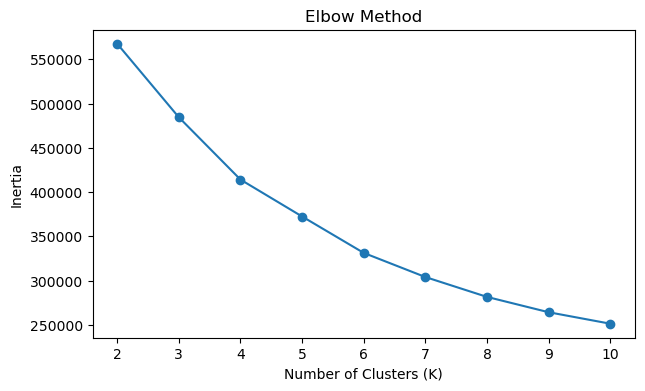

In [9]:
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(2, 11))
plt.show()

Yahan K = 4 ke around elbow sabse noticeable hai. Uske baad curve relatively gradually flatten ho rahi hai.

## 10. Train K-Means Clustering Model

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_features)

clusters[:10]

array([1, 0, 0, 0, 1, 1, 1, 1, 1, 0], dtype=int32)

## 11. Assign Customer Segments

In [11]:
segmentation_data["cluster"] = clusters

segmentation_data["cluster"].value_counts().sort_index()


cluster
0    45165
1    47485
2     3497
3     3853
Name: count, dtype: int64

## 12. Analyze Customer Segments

In [12]:
cluster_profile = segmentation_data.groupby("cluster")[
    [
        "age",
        "annual_income",
        "cibil_score",
        "account_balance",
        "total_transactions",
        "total_transaction_amount",
        "average_transaction_amount"
    ]
].mean().round(2)

cluster_profile

,age,annual_income,cibil_score,account_balance,total_transactions,total_transaction_amount,average_transaction_amount
cluster,,,,,,,
0,48.51,643749.87,692.84,450766.06,6.70,126021.27,19543.35
1,48.51,637673.49,689.12,829026.19,8.23,286046.11,35512.22
2,48.90,764382.61,692.53,33885030.03,7.46,245350.58,32970.48
3,48.45,7012050.35,692.39,1087263.17,7.48,206889.66,27636.52


## 13. Assign Segment Names

In [13]:
segment_names = {
    0: "Low Activity Customers",
    1: "Active Customers",
    2: "High Balance Customers",
    3: "High Income Customers"
}

segmentation_data["segment"] = segmentation_data["cluster"].map(segment_names)

segmentation_data[
    ["customer_id", "cluster", "segment"]
].head()

,customer_id,cluster,segment
0,1,1,Active Customers
1,2,0,Low Activity Customers
2,3,0,Low Activity Customers
3,4,0,Low Activity Customers
4,5,1,Active Customers


## 14. Segment Distribution

In [17]:
segmentation_data["segment"].value_counts()


segment
Active Customers          47485
Low Activity Customers    45165
High Income Customers      3853
High Balance Customers     3497
Name: count, dtype: int64

## 15. Segment Distribution Visualization

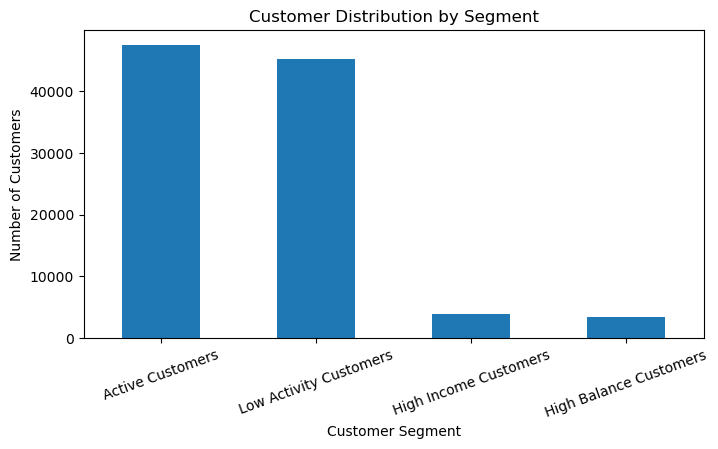

In [18]:
segment_counts = segmentation_data["segment"].value_counts()

segment_counts.plot(
    kind="bar",
    figsize=(8, 4),
    title="Customer Distribution by Segment"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

## 16. Customer Segment Prediction

In [19]:
def predict_customer_segment(
    age,
    annual_income,
    cibil_score,
    account_balance,
    total_transactions,
    total_transaction_amount,
    average_transaction_amount
):
    
    new_customer = pd.DataFrame([{
        "age": age,
        "annual_income": annual_income,
        "cibil_score": cibil_score,
        "account_balance": account_balance,
        "total_transactions": total_transactions,
        "total_transaction_amount": total_transaction_amount,
        "average_transaction_amount": average_transaction_amount
    }])
    
    new_customer_scaled = scaler.transform(new_customer)
    
    cluster = kmeans.predict(new_customer_scaled)[0]
    
    return segment_names[cluster]

In [20]:
predict_customer_segment(
    age=30,
    annual_income=800000,
    cibil_score=750,
    account_balance=200000,
    total_transactions=20,
    total_transaction_amount=400000,
    average_transaction_amount=20000
)

'Active Customers'

In [21]:
for cluster in sorted(segmentation_data["cluster"].unique()):
    
    sample = segmentation_data[
        segmentation_data["cluster"] == cluster
    ].iloc[0]
    
    prediction = predict_customer_segment(
        age=sample["age"],
        annual_income=sample["annual_income"],
        cibil_score=sample["cibil_score"],
        account_balance=sample["account_balance"],
        total_transactions=sample["total_transactions"],
        total_transaction_amount=sample["total_transaction_amount"],
        average_transaction_amount=sample["average_transaction_amount"]
    )
    
    print(
        f"Cluster {cluster} → "
        f"Expected: {segment_names[cluster]} | "
        f"Predicted: {prediction}"
    )

Cluster 0 → Expected: Low Activity Customers | Predicted: Low Activity Customers
Cluster 1 → Expected: Active Customers | Predicted: Active Customers
Cluster 2 → Expected: High Balance Customers | Predicted: High Balance Customers
Cluster 3 → Expected: High Income Customers | Predicted: High Income Customers


## 19. Save Model and Scaler

In [22]:
import joblib

joblib.dump(kmeans, "customer_segmentation_model.pkl")
joblib.dump(scaler, "customer_segmentation_scaler.pkl")

print("Model saved successfully.")
print("Scaler saved successfully.")

Model saved successfully.
Scaler saved successfully.
